In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from hmmlearn import hmm
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from hmmlearn.hmm import GaussianHMM



In [ ]:

# Đọc file dữ liệu đã qua xử lý feature trong csv
train_features=pd.read_csv('traffic_train_with_features.csv')

## XEM MA TRẬN TƯƠNG QUAN

--- Đang thực hiện Mini-tests ---


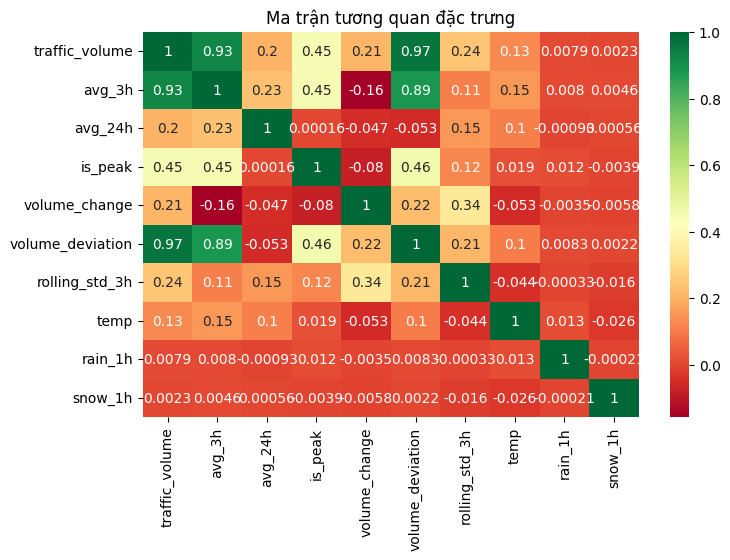

In [39]:


def perform_mini_tests(train_features):
    print("--- Đang thực hiện Mini-tests ---")
    cols = ['traffic_volume', 'avg_3h', 'avg_24h', 'is_peak','volume_change','volume_deviation','rolling_std_3h','temp','rain_1h','snow_1h']
    
    # 1. Heatmap
    plt.figure(figsize=(8,5))
    sns.heatmap(train_features[cols].corr(), annot=True, cmap='RdYlGn')
    plt.title("Ma trận tương quan đặc trưng")
    plt.show()
perform_mini_tests(train_features)



# Chọn được 5 bộ feature để làm cấu hình: 
# Bộ 1: ['traffic_volume', 'avg_24h', 'volume_deviation']
# Bộ 2: ['traffic_volume', 'avg_24h', 'volume_deviation', 'volume_change']
# Bộ 3: ['traffic_volume', 'is_peak', 'volume_change', 'rolling_std_3h']
# Bộ 4: ['avg_3h', 'volume_change', 'rolling_std_3h', 'is_peak']
# Bộ 5: ['traffic_volume', 'avg_24h'] 


In [ ]:
# 1. Định nghĩa 5 bộ feature
feature_sets = {

    "Bo_1": ['traffic_volume', 'avg_24h', 'volume_deviation'],

    "Bo_2": ['traffic_volume', 'avg_24h', 'volume_deviation', 'volume_change'],

    "Bo_3": ['traffic_volume', 'is_peak', 'volume_change', 'rolling_std_3h'],

    "Bo_4": ['avg_3h', 'volume_change', 'rolling_std_3h', 'is_peak'],

    "Bo_5": ['traffic_volume', 'avg_24h']# bộ cơ bản nhất

    
}


## CHẠY ƯỚC LƯỢNG 20 MODEL ĐỂ TÌM ĐƯỢC MODEL TỐI ƯU

In [44]:
N_range = range(2, 5)  # N = 2,3,4,5

In [45]:


results = []

for feature_name, cols in feature_sets.items():
    
    # lấy dữ liệu train theo feature set
    X = train_features[cols].dropna().values
    
    n_samples, n_features = X.shape

    for N in N_range:

        model = GaussianHMM(
            n_components=N,
            covariance_type="full",
            n_iter=100,
            random_state=42
        )

        # ===== EM algorithm =====
        model.fit(X)

        # log-likelihood
        log_likelihood = model.score(X)

        # ===== số tham số để tính BIC/AIC =====
        # transition + emission + initial probs
        n_params = (
            N * (N - 1) +                 # transition matrix
            N * n_features +              # mean
            N * n_features * (n_features + 1) / 2 +  # covariance
            N - 1                         # initial prob
        )

        bic = -2 * log_likelihood + n_params * np.log(n_samples)
        aic = -2 * log_likelihood + 2 * n_params

        results.append({
            "feature_set": feature_name,
            "N": N,
            "log_likelihood": log_likelihood,
            "bic": bic,
            "aic": aic
        })

Model is not converging.  Current: -213197.82094362166 is not greater than -213153.83852103364. Delta is -43.98242258801474
Model is not converging.  Current: -207027.47143363827 is not greater than -206757.859497847. Delta is -269.6119357912685
Model is not converging.  Current: -203681.32302203256 is not greater than -202926.9744179824. Delta is -754.3486040501739
Model is not converging.  Current: -379421.1293170462 is not greater than -377939.0418409421. Delta is -1482.0874761040905
Model is not converging.  Current: -372742.4708980059 is not greater than -371862.4025004593. Delta is -880.0683975465945
Model is not converging.  Current: -362344.1357866862 is not greater than -361200.06578037725. Delta is -1144.0700063089607
Model is not converging.  Current: -385678.2493391263 is not greater than -385678.2493390249. Delta is -1.0139774531126022e-07


In [ ]:
# --- Bảng kết quả ---
results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(by="bic", ascending=True)

display(results_df_sorted)

,feature_set,N,log_likelihood,bic,aic
2,Bo_1,4,-202258.269152,405022.910310,404618.538304
1,Bo_1,3,-206952.799380,414253.108961,413975.598760
0,Bo_1,2,-213037.332849,426283.171817,426116.665697
3,Bo_1,5,-218691.055634,438067.202804,437520.111267
19,Bo_5,5,-314336.180179,629158.874639,628770.360359
18,Bo_5,4,-319610.465346,639568.440891,639290.930691
17,Bo_5,3,-328134.693811,656497.751468,656315.387622
16,Bo_5,2,-328403.706028,656936.487274,656833.412057
15,Bo_4,5,-359678.090925,720289.494960,719544.181851
11,Bo_3,5,-361481.512281,723896.337671,723151.024562


In [ ]:
# Làm tròn kết quả
display(
    results_df_sorted.style
    .format({
        "log_likelihood": "{:.2f}",
        "bic": "{:.2f}",
        "aic": "{:.2f}"
    })
    .highlight_min(subset=["bic"], color="lightgreen")
)

,feature_set,N,log_likelihood,bic,aic
2,Bo_1,4,-202258.27,405022.91,404618.54
1,Bo_1,3,-206952.80,414253.11,413975.60
0,Bo_1,2,-213037.33,426283.17,426116.67
3,Bo_1,5,-218691.06,438067.20,437520.11
11,Bo_5,5,-314336.18,629158.87,628770.36
10,Bo_5,4,-319610.47,639568.44,639290.93
9,Bo_5,3,-328134.69,656497.75,656315.39
8,Bo_5,2,-328403.71,656936.49,656833.41
19,Bo_4,5,-359678.09,720289.49,719544.18
7,Bo_3,5,-361481.51,723896.34,723151.02
